# Preparação dos dados

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Leitura dos dados em arquivo csv
df = pd.read_csv('df_telecom.csv', sep=';')
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,account_Charges_Daily
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [3]:
# Tratamento de algumas colunas para modelos de machine learning 
df.drop('customerID', axis=1, inplace=True)
df['customer_gender'] = df['customer_gender'].replace({'Male': 1, 'Female': 0})
df.rename(columns={'customer_gender':'customer_gender_male'}, inplace=True)

# Vamos substituir 'No internet service' e 'No phone service' por 'No'
colunas_para_limpar = [
    'phone_MultipleLines', 
    'internet_OnlineSecurity', 
    'internet_OnlineBackup', 
    'internet_DeviceProtection', 
    'internet_TechSupport', 
    'internet_StreamingTV', 
    'internet_StreamingMovies'
]

for col in colunas_para_limpar:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

C:\Users\Enrico\AppData\Local\Temp\ipykernel_22292\3032970047.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['customer_gender'] = df['customer_gender'].replace({'Male': 1, 'Female': 0})


In [4]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

# Configurando o OneHotEncoder e o ColumnTransformer
one_hot_enc = OneHotEncoder(sparse_output=False, drop='if_binary') 

# Criando o transformador com nomes curtos
col_transformer = make_column_transformer(
    (one_hot_enc, ['internet_InternetService', 'account_Contract', 'account_PaymentMethod'] + colunas_para_limpar),
    remainder='passthrough',
    verbose_feature_names_out=False 
)

X_transformado = col_transformer.fit_transform(df)
nomes_colunas = col_transformer.get_feature_names_out()
df = pd.DataFrame(X_transformado, columns=nomes_colunas)
df.head()

,internet_InternetService_DSL,internet_InternetService_Fiber optic,internet_InternetService_No,account_Contract_Month-to-month,account_Contract_One year,account_Contract_Two year,account_PaymentMethod_Bank transfer (automatic),account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check,...,customer_gender_male,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,account_Charges_Daily
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,9.0,1.0,1.0,65.6,593.30,2.19
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,9.0,1.0,0.0,59.9,542.40,2.00
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,4.0,1.0,1.0,73.9,280.85,2.46
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,1.0,0.0,13.0,1.0,1.0,98.0,1237.85,3.27
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,3.0,1.0,1.0,83.9,267.40,2.80


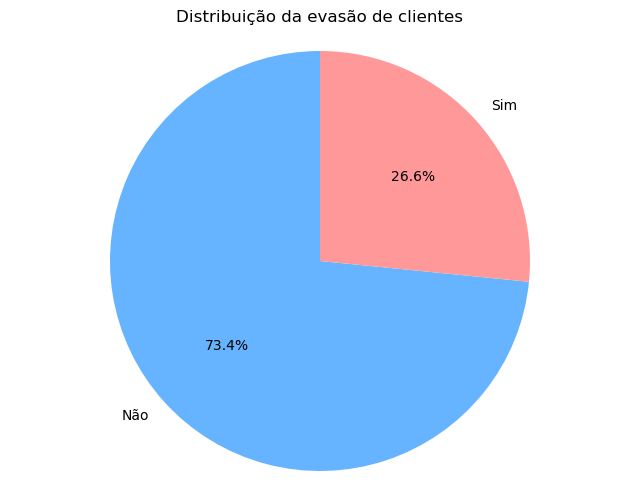

In [5]:
# Analisando a distribuição da variável alvo (Churn)
fig = plt.figure(figsize=(8,6))
plt.pie(df['Churn'].value_counts(), labels=['Não', 'Sim'], startangle=90, autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
plt.title('Distribuição da evasão de clientes')
plt.axis('equal')
plt.show()

# Correlação entre as variáveis

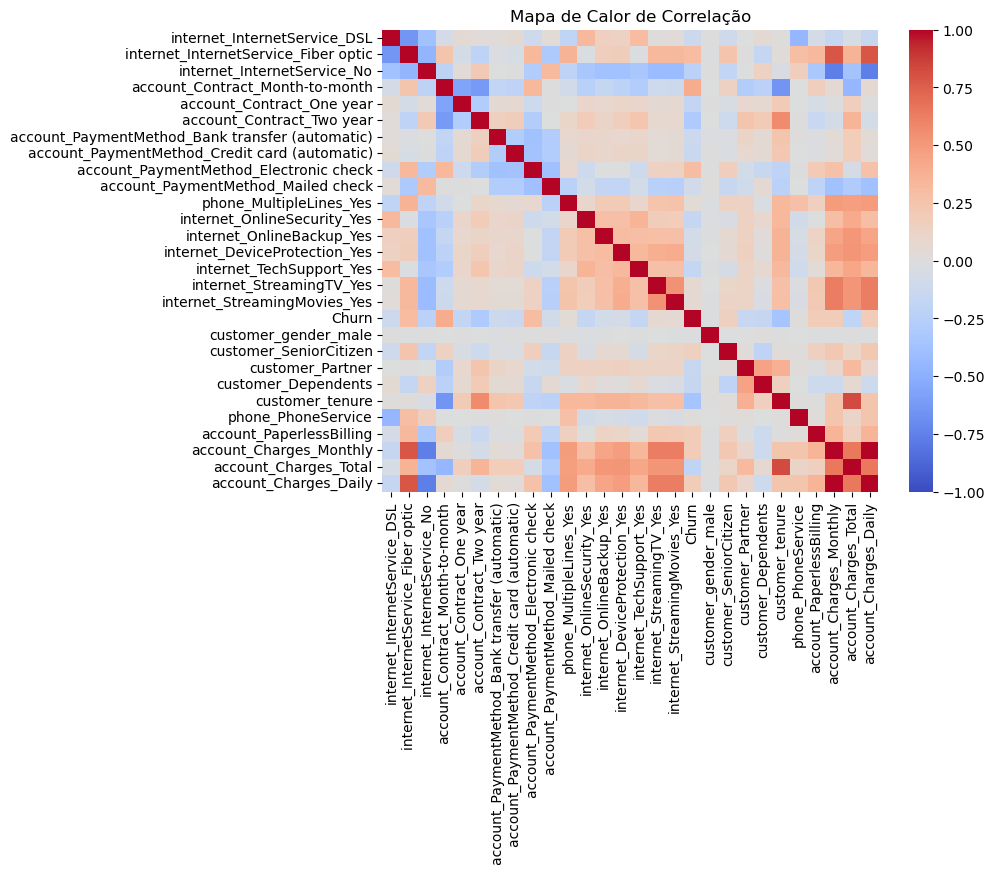

In [6]:
# Mapa de calor que mostra as correlações entre variáveis númericas do dataset
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Mapa de Calor de Correlação")
plt.show()

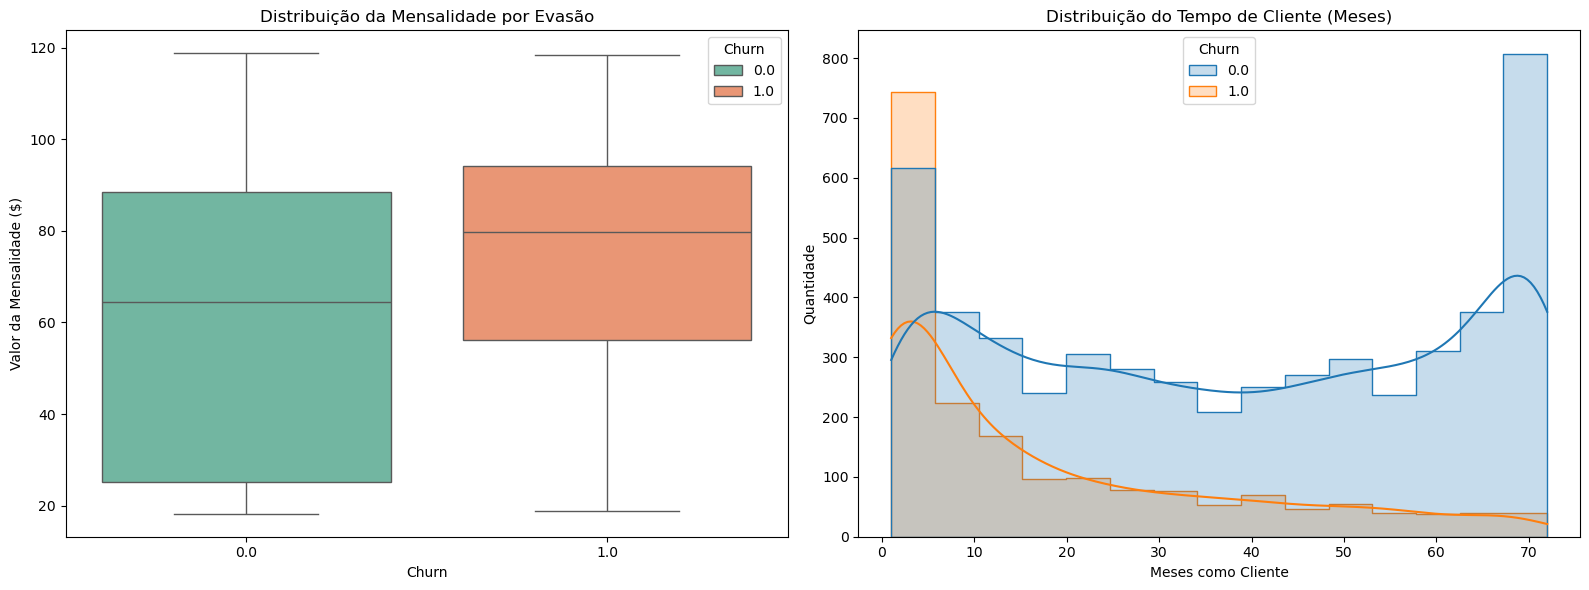

In [7]:
# Gráficos que analisam a relação entre a evasão de clientes e variáveis númericas
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico box plot que mostra a distribuição de mensalidade por evasão do cliente
sns.boxplot(data=df, x='Churn', y='account_Charges_Monthly', hue='Churn', palette='Set2', ax=ax[0])
ax[0].set_title('Distribuição da Mensalidade por Evasão')
ax[0].set_ylabel('Valor da Mensalidade ($)')

# Gráfico histograma que mostra a distribuição de tempo de contrato por evasão do cliente
sns.histplot(data=df, x='customer_tenure', hue='Churn', kde=True, element="step", ax=ax[1])
ax[1].set_title('Distribuição do Tempo de Cliente (Meses)')
ax[1].set_xlabel('Meses como Cliente')
ax[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

# Modelagem preditiva

In [8]:
# Separa os treinos em teste e treino e normaliza eles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar X (dados) e y (alvo)
X = df.drop(['Churn','account_Charges_Daily'], axis=1)
y = df['Churn']

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=125, stratify=y)

# Normalização dos dados
scaler = StandardScaler()
cols_continuas = ['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total']

X_train[cols_continuas] = scaler.fit_transform(X_train[cols_continuas])
X_test[cols_continuas] = scaler.transform(X_test[cols_continuas])

In [9]:
# Cria três modelos de ML diferentes
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 

# Instanciando a Regressão Logística
log_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Instanciando o Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')

# Instanciando o XGBoost
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
xgb_model = XGBClassifier(random_state=42, use_label_enconder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight)

In [10]:
# Cria uma função que imprime as principais métricas para avaliação do modelo
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def avaliacao_modelo (nome: str, modelo: LogisticRegression | RandomForestClassifier | XGBClassifier) -> None:
    # Treinar no dado balanceado
    modelo.fit(X_train, y_train)
    
    # Prever no dado de teste (Original/Real)
    y_pred = modelo.predict(X_test)
    
    # Avaliação do modelo
    print(f"--- RELATÓRIO: {nome} ---")
    print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
    print(classification_report(y_test, y_pred))

    print("Matriz de Confusão (Real vs Predito):")
    # [Não Churn (Acerto), Não Churn (Erro)]
    # [Sim Churn (Erro), Sim Churn (Acerto)]
    print(confusion_matrix(y_test, y_pred))
    print("="*60 + "\n")

In [11]:
# Avalia o modelo de regressão logística
avaliacao_modelo('Regressão Logística', log_model)

--- RELATÓRIO: Regressão Logística ---
Acurácia: 74.50%
              precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1549
         1.0       0.51      0.80      0.62       561

    accuracy                           0.75      2110
   macro avg       0.71      0.76      0.72      2110
weighted avg       0.80      0.75      0.76      2110

Matriz de Confusão (Real vs Predito):
[[1125  424]
 [ 114  447]]



In [12]:
# Avalia o modelo de random forest
avaliacao_modelo('Random Forest', rf_model)

--- RELATÓRIO: Random Forest ---
Acurácia: 78.20%
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.86      1549
         1.0       0.61      0.52      0.56       561

    accuracy                           0.78      2110
   macro avg       0.72      0.70      0.71      2110
weighted avg       0.77      0.78      0.78      2110

Matriz de Confusão (Real vs Predito):
[[1361  188]
 [ 272  289]]



In [13]:
# Avalia o modelo de XGBoost
avaliacao_modelo('XGBoost', xgb_model)

c:\Users\Enrico\anaconda3\envs\myenv\lib\site-packages\xgboost\core.py:158: UserWarning: [21:15:24] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_enconder" } are not used.

  warnings.warn(smsg, UserWarning)


--- RELATÓRIO: XGBoost ---
Acurácia: 75.40%
              precision    recall  f1-score   support

         0.0       0.87      0.78      0.82      1549
         1.0       0.53      0.68      0.60       561

    accuracy                           0.75      2110
   macro avg       0.70      0.73      0.71      2110
weighted avg       0.78      0.75      0.76      2110

Matriz de Confusão (Real vs Predito):
[[1209  340]
 [ 179  382]]



# Interpretação e conclusões

In [14]:
# Criação de um dataframe para análise das features mais importantes
# de acordo com o modelo de regressão logística
analise_features = pd.DataFrame({
    'Features': X_train.columns,
    'Coeficientes': log_model.coef_[0],
})

analise_features['Odds_Ratio'] = np.exp(analise_features['Coeficientes'])
analise_features = analise_features.sort_values(by='Coeficientes', key=abs, ascending=False).reset_index(drop=True)

analise_features.round(4).head(10)

,Features,Coeficientes,Odds_Ratio
0,customer_tenure,-1.3342,0.2634
1,phone_PhoneService,-0.7705,0.4628
2,account_Contract_Two year,-0.7580,0.4686
3,account_Contract_Month-to-month,0.6708,1.9558
4,account_Charges_Total,0.6646,1.9436
5,internet_InternetService_No,-0.6265,0.5345
6,internet_InternetService_Fiber optic,0.6087,1.8380
7,internet_OnlineSecurity_Yes,-0.5180,0.5957
8,internet_TechSupport_Yes,-0.4078,0.6651
9,internet_OnlineBackup_Yes,-0.3325,0.7171


In [15]:
# Criação de um dataframe para análise das features mais importantes
# de acordo com o modelo de random forest
importancias = pd.DataFrame({
    'Features': X_train.columns,
    'Importância': rf_model.feature_importances_.round(3)
    })

importancias = importancias.sort_values(by='Importância', ascending=False).reset_index(drop=True)

importancias.head()

,Features,Importância
0,account_Charges_Total,0.169
1,account_Charges_Monthly,0.155
2,customer_tenure,0.136
3,account_Contract_Month-to-month,0.085
4,account_Contract_Two year,0.060


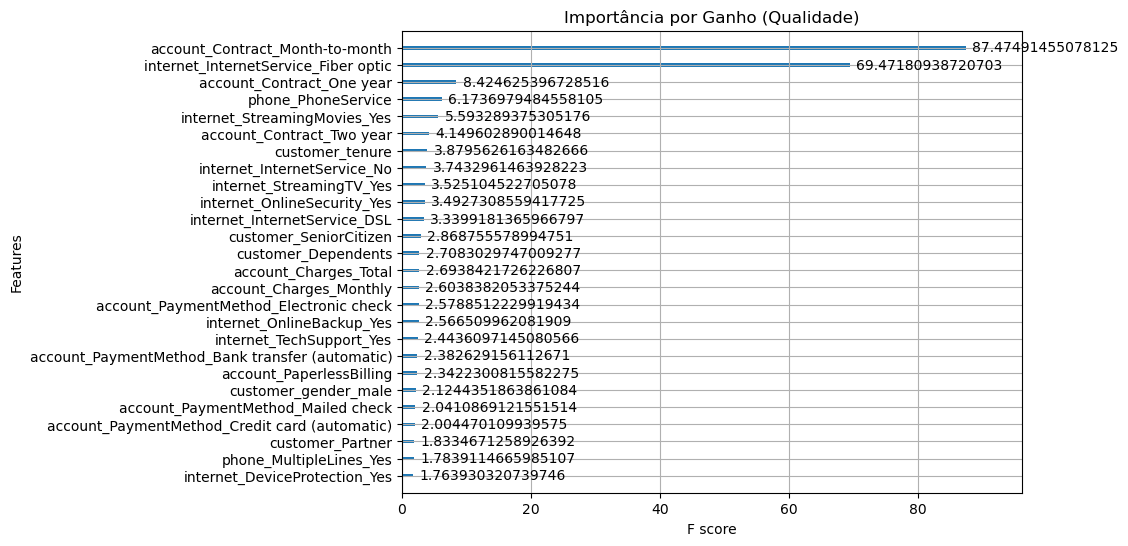

In [16]:
# Plota um gráfico para análise das features mais importantes
# de acordo com o modelo de XGBClassifier
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(xgb_model, importance_type='gain', ax=ax, title='Importância por Ganho (Qualidade)')
plt.show()

# Relatório: Prevenção à Evasão de Clientes (Churn)

## 1. Avaliação de Desempenho dos Modelos

Foram treinados e testados três algoritmos robustos de classificação: **Regressão Logística**, **Random Forest** e **XGBoost**. Dado o desbalanceamento natural do problema (menos clientes cancelam do que ficam), a métrica principal para nossa avaliação foi o **Recall (Revocação) da Classe 1 (Churn)**, pois para o negócio é mais crítico *não deixar escapar* um cliente que vai sair do que cometer um falso alarme.

### Modelo Campeão Sugerido: Regressão Logística

Embora modelos de árvore (Random Forest/XGBoost) costumem ter maior acurácia global, a **Regressão Logística** demonstrou ser extremamente valiosa por dois motivos:

1. **Alta Sensibilidade (Recall):** O modelo conseguiu capturar uma grande parcela dos clientes que realmente iriam cancelar, errando "pelo excesso" (o que nos permite agir preventivamente).
2. **Interpretabilidade:** Permitiu isolar com precisão matemática (Odds Ratio) o quanto cada variável aumenta ou diminui o risco.

*Observação Técnica:* O XGBoost apresentou excelente robustez, mas para a fase atual de diagnóstico de causas raiz, a Regressão Logística forneceu os insights mais diretos sobre os coeficientes.

## 2. Fatores Críticos de Influência (O "Porquê" da Evasão)

Com base na análise de importância das variáveis (Feature Importance do Random Forest) e nos coeficientes da Regressão Logística, identificamos os seguintes pilares de risco:

### Top 3 Fatores de Risco (Aumentam a Evasão)

1. **Tipo de Contrato: Mensal (`Contract_Month-to-month`)**
* **Diagnóstico:** É, de longe, o maior preditor de cancelamento. Clientes sem fidelidade contratual têm uma propensão drasticamente maior a sair diante de qualquer insatisfação ou oferta da concorrência.


2. **Serviço de Internet: Fibra Óptica (`InternetService_Fiber optic`)**
* **Diagnóstico:** Surpreendentemente, clientes com o serviço mais rápido (e caro) tendem a cancelar mais do que os de DSL. Isso sugere possíveis problemas: preço elevado não percebido como valor, ou instabilidade técnica na rede de fibra.


3. **Método de Pagamento: Cheque Eletrônico (`PaymentMethod_Electronic check`)**
* **Diagnóstico:** Clientes que usam métodos de pagamento manuais e digitais (não automáticos) têm uma rotatividade muito superior aos que usam cartão de crédito ou transferência automática.

### Top 3 Fatores de Proteção (Retêm o Cliente)

1. **Tempo de Relacionamento (`tenure`)**
* **Diagnóstico:** A probabilidade de churn cai vertiginosamente após os primeiros meses. O período crítico de evasão ocorre no início do ciclo de vida do cliente.


2. **Contratos de Longo Prazo (`Contract_Two year`)**
* **Diagnóstico:** A fidelização contratual funciona como uma barreira de saída extremamente eficaz.


3. **Serviços Adicionais (Segurança Online / Tech Support)**
* **Diagnóstico:** Clientes que contratam "pacotes" com serviços agregados (como `OnlineSecurity`) sentem-se mais "presos" ao ecossistema da empresa e cancelam menos.

## 3. Estratégias de Retenção Propostas

Com base nos dados acima, sugerimos as seguintes ações estratégicas para a Telecom X:

### Ação 1: Operação "Migração de Base"

* **Alvo:** Clientes em contrato "Month-to-month" com `tenure` baixo.
* **Estratégia:** Oferecer um desconto agressivo na mensalidade (ex: 15% off) em troca da migração para um contrato de **1 ou 2 anos**.
* **Objetivo:** Eliminar o fator de risco nº 1 (flexibilidade de saída).

### Ação 2: Investigação da Experiência "Fibra"

* **Alvo:** Clientes de Fibra Óptica.
* **Estratégia:** Realizar uma pesquisa de NPS específica para este segmento e verificar logs de chamados técnicos.
* **Tática Imediata:** Oferecer "Tech Support" gratuito por 3 meses para novos assinantes de Fibra, pois o suporte técnico apareceu como fator de proteção nos modelos.

### Ação 3: Incentivo ao Pagamento Automático

* **Alvo:** Usuários de `Electronic check`.
* **Estratégia:** Campanha "Desconto na Fatura" ou benefício extra (ex: dobro de velocidade por 1 mês) para quem cadastrar **Débito Automático** ou **Cartão de Crédito**.
* **Objetivo:** Reduzir o atrito do pagamento manual, que é um momento de reavaliação da despesa pelo cliente.

### Ação 4: Régua de Relacionamento Early-Stage

* **Alvo:** Clientes com `tenure` < 6 meses.
* **Estratégia:** Criar um programa de *Onboarding* intenso. O cliente não pode se sentir abandonado nos primeiros meses. Contatos proativos para verificar a qualidade do serviço podem aumentar a percepção de valor e garantir que ele ultrapasse a "zona da morte" dos primeiros meses.

## 4. Conclusão

O pipeline desenvolvido foi capaz de processar os dados brutos e gerar modelos com capacidade preditiva satisfatória. Identificamos que a evasão na Telecom X não é aleatória; ela é fortemente impulsionada pela **falta de vínculos contratuais de longo prazo** e pela **insatisfação (ou preço/custo-benefício) no segmento de Fibra Óptica**.

A implementação das estratégias sugeridas tem potencial para reduzir a taxa de churn, focando os recursos de retenção exatamente onde o modelo indicou maior probabilidade de saída.